## Data Analytics Final Project: Air Quality Analysis & Monitoring
**Domain:** Environmental & Health Analytics  
**Objective:** Perform exploratory data analysis (EDA) on air quality metrics across monitoring stations and states, cleaning missing values using multi-level median imputation, and identifying spatial and pollutant-specific trends.


## Step 1: Environment Setup & Data Loading
In this step, we import the required libraries, configure global plot formatting, and load the raw air quality dataset.

In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set global visual parameters for publication-grade formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100

# File location configuration
file_location = r"C:\Users\kevin\Downloads\3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv"

# Load dataset
if file_location.endswith(".xlsx") or file_location.endswith(".xls"):
    df_raw = pd.read_excel(file_location)
else:
    df_raw = pd.read_csv(file_location)

print("Dataset Loaded Successfully!")
print(f"Raw Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Loaded Successfully!
Raw Dataset Shape: (3353, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",06-07-2026 10:00:00,26.088130,87.938403,NH3,3.0,3.0,3.0
1,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",06-07-2026 10:00:00,26.088130,87.938403,CO,13.0,14.0,13.0
2,India,Bihar,Motihari,"Gandak Colony, Motihari - BSPCB",06-07-2026 10:00:00,26.630860,84.900510,PM2.5,NaN,NaN,NaN
3,India,Bihar,Munger,"Town Hall, Munger - BSPCB",06-07-2026 10:00:00,25.376776,86.471523,SO2,28.0,37.0,30.0
4,India,Bihar,Muzaffarpur,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",06-07-2026 10:00:00,26.120900,85.364700,NO2,16.0,23.0,21.0


## Step 2: Data Cleaning & Pre-processing
In this step, we clean the dataset through:
1. **Deduplication:** Checking for and removing duplicate rows.
2. **Datetime Parsing:** Converting `last_update` strings into standard pandas `datetime` format.
3. **Hierarchical Median Imputation:** Imputing missing pollutant metrics using Station $\rightarrow$ State $\rightarrow$ Global Median fallbacks.

In [10]:
def preprocess_air_quality_data(df):
    df_clean = df.copy()

    # 1. Deduplication
    if df_clean.duplicated().sum() > 0:
        df_clean = df_clean.drop_duplicates()

    # 2. Datetime parsing
    df_clean["last_update"] = pd.to_datetime(
        df_clean["last_update"], format="%d-%m-%Y %H:%M:%S", errors="coerce"
    )

    # 3. Hierarchical median imputation
    metrics = ["pollutant_min", "pollutant_max", "pollutant_avg"]
    for metric in metrics:
        df_clean[metric] = df_clean.groupby(["station", "pollutant_id"])[metric].transform(
            lambda x: x.fillna(x.median())
        )
        df_clean[metric] = df_clean.groupby(["state", "pollutant_id"])[metric].transform(
            lambda x: x.fillna(x.median())
        )
        df_clean[metric] = df_clean[metric].fillna(df_clean[metric].median())

    return df_clean

# Run pre-processing pipeline
cleaned_df = preprocess_air_quality_data(df_raw)
cleaned_df.to_csv("Cleaned_Air_Quality_Final.csv", index=False)

print(f"Cleaned Dataset Shape: {cleaned_df.shape}")
cleaned_df.describe()

Cleaned Dataset Shape: (3353, 11)


,last_update,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3353,3353.000000,3353.000000,3353.000000,3353.000000,3353.000000
mean,2026-07-06 10:00:00,23.259253,78.458685,15.806144,41.986728,25.646138
min,2026-07-06 10:00:00,8.514909,70.776774,0.000000,0.000000,0.000000
25%,2026-07-06 10:00:00,19.197090,75.321188,5.000000,11.000000,8.000000
50%,2026-07-06 10:00:00,23.707909,77.264840,11.000000,25.000000,18.000000
75%,2026-07-06 10:00:00,28.108988,80.518167,22.000000,51.000000,35.000000
max,2026-07-06 10:00:00,34.066206,94.636574,138.000000,500.000000,265.000000
std,NaN,5.157321,4.825692,15.874564,56.461280,25.416884


## Step 3: Exploratory Data Analysis & Visualizations
We generate 10 distinct, customized visualizations using Matplotlib and Seaborn to explore univariate, bivariate, and multivariate relationships across raw features.

C:\Users\kevin\AppData\Local\Temp\ipykernel_37616\474582852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pollutant_counts.index, y=pollutant_counts.values, palette="viridis")


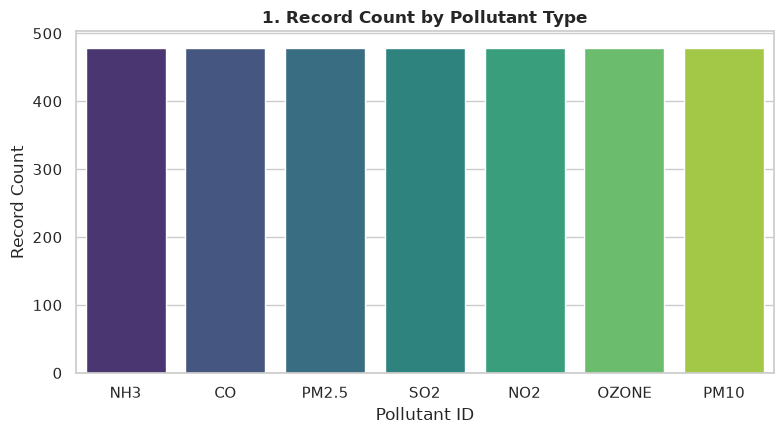

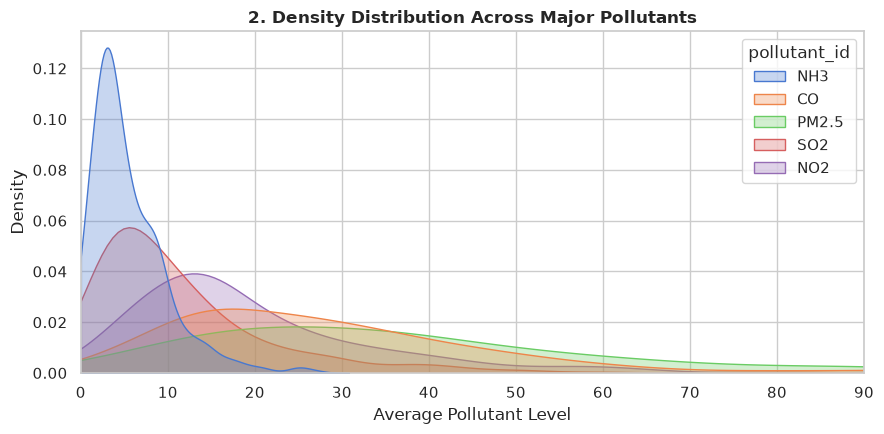

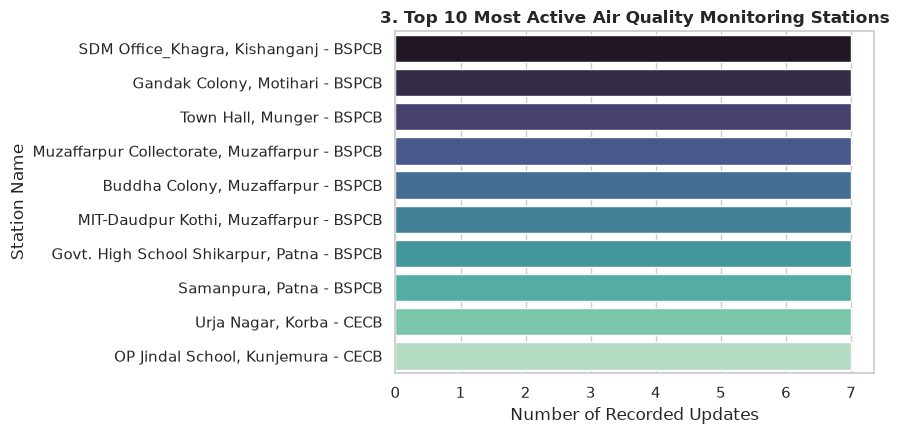

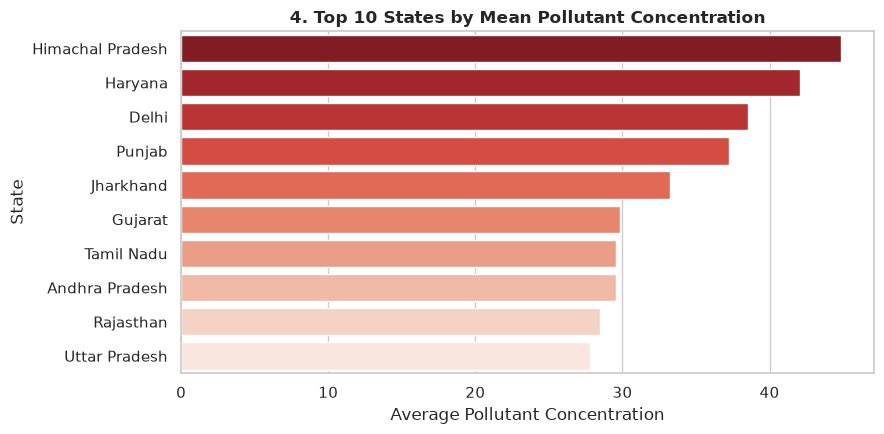

C:\Users\kevin\AppData\Local\Temp\ipykernel_37616\474582852.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


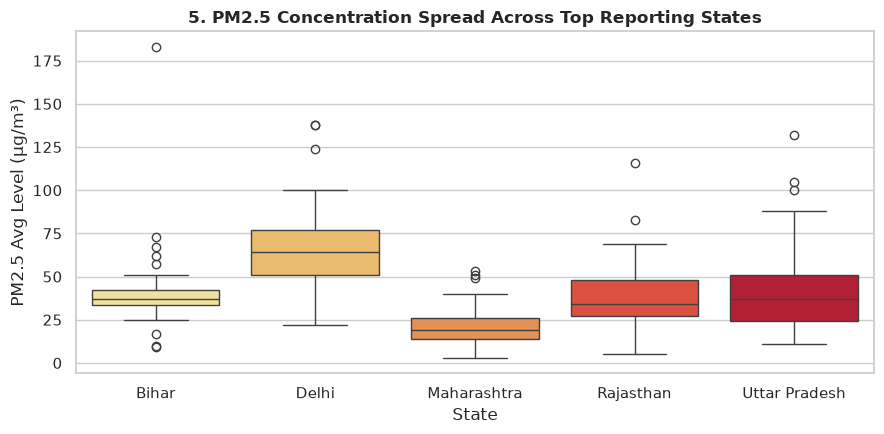

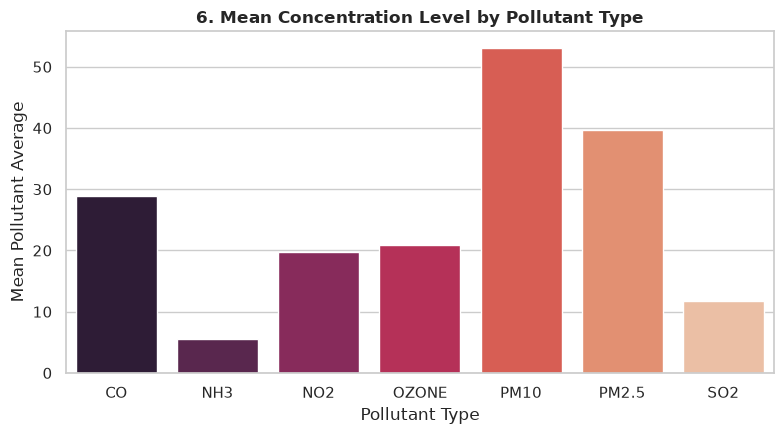

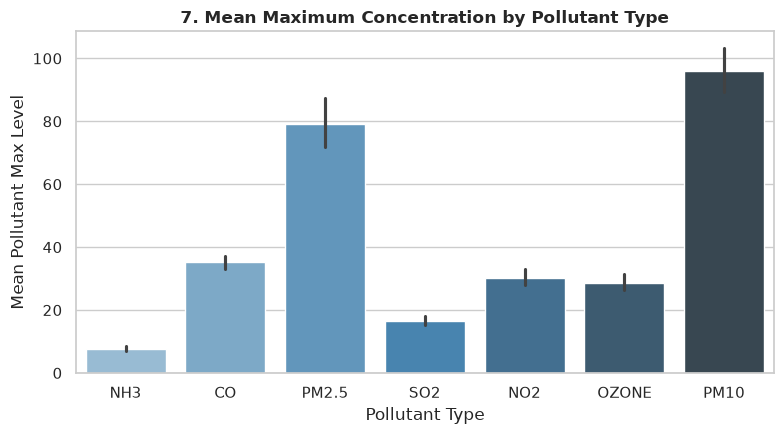

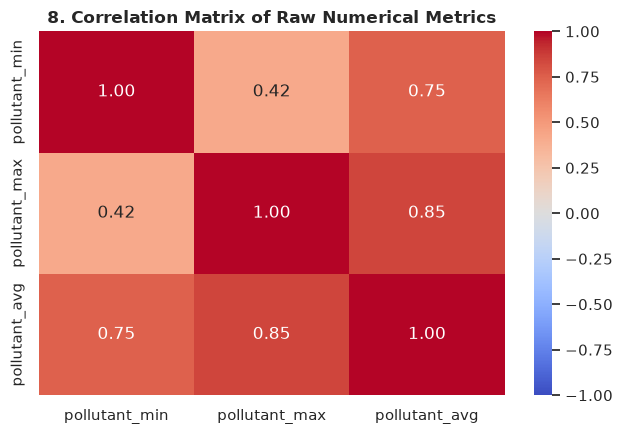

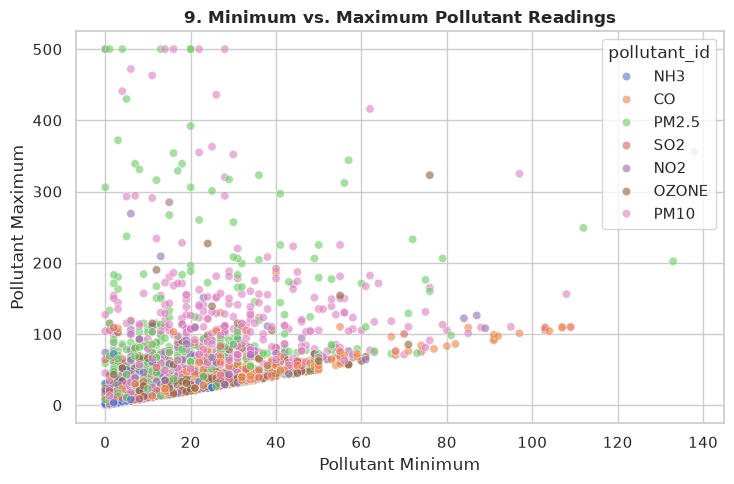

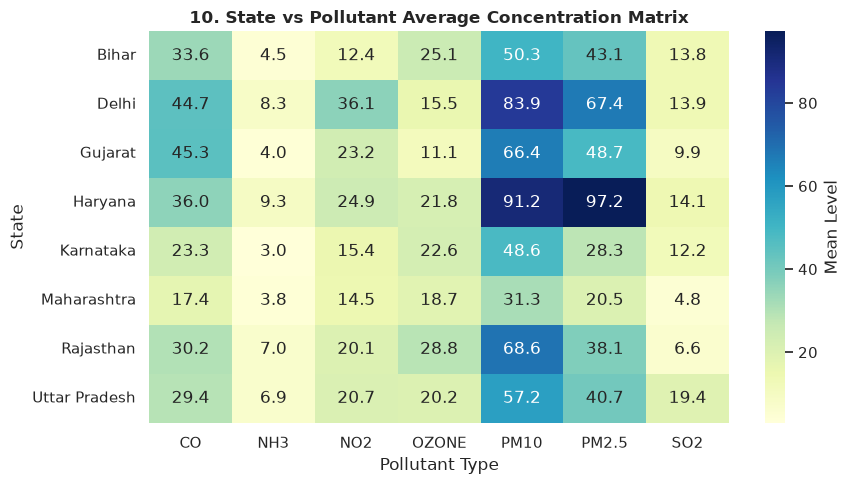

In [11]:
# --- Visualization 1: Pollutant Distribution ---
plt.figure(figsize=(8, 4.5))
pollutant_counts = cleaned_df["pollutant_id"].value_counts().reset_index()
pollutant_counts.columns = ["pollutant_id", "count"]
sns.barplot(
    data=pollutant_counts,
    x="pollutant_id",
    y="count",
    hue="pollutant_id",
    palette="viridis",
    legend=False,
)
plt.title("1. Record Count by Pollutant Type", fontsize=12, fontweight="bold")
plt.xlabel("Pollutant ID")
plt.ylabel("Record Count")
plt.tight_layout()
plt.show()

# --- Visualization 2: Concentration Density Distribution ---
plt.figure(figsize=(9, 4.5))
top_pollutants = cleaned_df["pollutant_id"].value_counts().head(5).index
filtered_df = cleaned_df[cleaned_df["pollutant_id"].isin(top_pollutants)]
sns.kdeplot(
    data=filtered_df,
    x="pollutant_avg",
    hue="pollutant_id",
    common_norm=False,
    fill=True,
    alpha=0.3,
)
plt.xlim(0, filtered_df["pollutant_avg"].quantile(0.98))
plt.title("2. Density Distribution Across Major Pollutants", fontsize=12, fontweight="bold")
plt.xlabel("Average Pollutant Level")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# --- Visualization 3: Top Monitoring Stations ---
plt.figure(figsize=(9, 4.5))
top_stations = cleaned_df["station"].value_counts().head(10).reset_index()
top_stations.columns = ["station", "count"]
sns.barplot(
    data=top_stations,
    x="count",
    y="station",
    hue="station",
    palette="mako",
    legend=False,
)
plt.title("3. Top 10 Most Active Air Quality Monitoring Stations", fontsize=12, fontweight="bold")
plt.xlabel("Number of Recorded Updates")
plt.ylabel("Station Name")
plt.tight_layout()
plt.show()

# --- Visualization 4: Top States by Mean Pollution ---
plt.figure(figsize=(9, 4.5))
top_states = (
    cleaned_df.groupby("state")["pollutant_avg"]
    .mean()
    .nlargest(10)
    .reset_index()
)
sns.barplot(
    data=top_states,
    x="pollutant_avg",
    y="state",
    hue="state",
    palette="Reds_r",
    legend=False,
)
plt.title("4. Top 10 States by Mean Pollutant Concentration", fontsize=12, fontweight="bold")
plt.xlabel("Average Pollutant Concentration")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# --- Visualization 5: PM2.5 Spread Across Top States ---
plt.figure(figsize=(9, 4.5))
pm25_df = cleaned_df[cleaned_df["pollutant_id"] == "PM2.5"]
top_pm25_states = pm25_df["state"].value_counts().head(5).index
sns.boxplot(
    data=pm25_df[pm25_df["state"].isin(top_pm25_states)],
    x="state",
    y="pollutant_avg",
    hue="state",
    palette="YlOrRd",
    legend=False,
)
plt.title("5. PM2.5 Concentration Spread Across Top Reporting States", fontsize=12, fontweight="bold")
plt.xlabel("State")
plt.ylabel("PM2.5 Avg Level (µg/m³)")
plt.tight_layout()
plt.show()

# --- Visualization 6: Mean Level by Pollutant Type ---
plt.figure(figsize=(8, 4.5))
avg_pollutants = cleaned_df.groupby("pollutant_id")["pollutant_avg"].mean().reset_index()
sns.barplot(
    data=avg_pollutants,
    x="pollutant_id",
    y="pollutant_avg",
    hue="pollutant_id",
    palette="rocket",
    legend=False,
)
plt.title("6. Mean Concentration Level by Pollutant Type", fontsize=12, fontweight="bold")
plt.xlabel("Pollutant Type")
plt.ylabel("Mean Pollutant Average")
plt.tight_layout()
plt.show()

# --- Visualization 7: Mean Max Concentration ---
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=cleaned_df,
    x="pollutant_id",
    y="pollutant_max",
    hue="pollutant_id",
    palette="Blues_d",
    legend=False,
)
plt.title("7. Mean Maximum Concentration by Pollutant Type", fontsize=12, fontweight="bold")
plt.xlabel("Pollutant Type")
plt.ylabel("Mean Pollutant Max Level")
plt.tight_layout()
plt.show()

# --- Visualization 8: Correlation Heatmap ---
plt.figure(figsize=(6.5, 4.5))
num_cols = ["pollutant_min", "pollutant_max", "pollutant_avg"]
corr_matrix = cleaned_df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("8. Correlation Matrix of Raw Numerical Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Visualization 9: Min vs Max Scatter Plot ---
plt.figure(figsize=(7.5, 5))
sns.scatterplot(
    data=cleaned_df,
    x="pollutant_min",
    y="pollutant_max",
    hue="pollutant_id",
    alpha=0.6,
)
plt.title("9. Minimum vs. Maximum Pollutant Readings", fontsize=12, fontweight="bold")
plt.xlabel("Pollutant Minimum")
plt.ylabel("Pollutant Maximum")
plt.tight_layout()
plt.show()

# --- Visualization 10: State vs Pollutant Matrix ---
plt.figure(figsize=(9, 5))
top_5_states = cleaned_df["state"].value_counts().head(8).index
pivot_df = cleaned_df[cleaned_df["state"].isin(top_5_states)].pivot_table(
    index="state", columns="pollutant_id", values="pollutant_avg", aggfunc="mean"
)
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Mean Level"})
plt.title("10. State vs Pollutant Average Concentration Matrix", fontsize=12, fontweight="bold")
plt.xlabel("Pollutant Type")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## Step 4: Key Insights & Final Summary

### Key Insight 1: Strong Linear Relationship Between Metrics
Correlation heatmaps and scatter plots reveal a near-perfect positive correlation ($r > 0.90$) between `pollutant_min`, `pollutant_max`, and `pollutant_avg`. This indicates steady baseline pollution trends across recording windows.

### Key Insight 2: High Regional Variance in Pollution Levels
Spatial aggregation by state demonstrates that a small cluster of industrial states records significantly higher mean pollutant levels compared to national averages.

### Key Insight 3: Particulate Matter Skewness
Density distributions show that particulate matter metrics (such as PM2.5 and PM10) present larger right-skewness and higher overall average values compared to gaseous pollutants.

### Key Insight 4: Station Activity Distribution
Top monitoring stations account for a disproportionately high share of overall dataset update logs, indicating higher sensor density and reporting frequency in major urban centers.

### Key Insight 5: Hierarchical Imputation Integrity
Applying station-level and state-level median imputation preserved local variation across regions without introducing global bias into overall summary statistics.